# Financial Risk Analysis with Python- Blackrock 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("blackrock.csv")
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,109,CUST1913,ACC64393,Credit,Withdrawal,Home Loan,Firm A,West,Manager 1,17-07-2023,47387.11457,2980.571037,0.780701,784,170
1,19,CUST1569,ACC66190,Current,Payment,Personal Loan,Firm C,South,Manager 4,13-01-2023,55806.54015,27996.690070,0.299268,336,197
2,14,CUST5558,ACC71426,Current,Withdrawal,Mutual Fund,Firm C,North,Manager 2,28-09-2023,51080.47837,81482.156180,0.388445,712,95
3,107,CUST4241,ACC49422,Loan,Deposit,Credit Card,Firm D,Central,Manager 1,05-02-2023,70472.70472,39598.371940,0.561809,414,168
4,7,CUST2578,ACC88252,Loan,Deposit,Savings Account,Firm B,East,Manager 4,19-11-2023,29830.48767,111731.993700,0.655635,391,20


#### df.head() gives the first 5 records in the dataset.

In [3]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='str')

#### df.columns lists all the column names in the dataset.

In [4]:
df.shape

(800, 15)

#### There are 800 rows and 15 columns in the dataset.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    str    
 2   AccountID          800 non-null    str    
 3   AccountType        800 non-null    str    
 4   TransactionType    800 non-null    str    
 5   Product            800 non-null    str    
 6   Firm               800 non-null    str    
 7   Region             800 non-null    str    
 8   Manager            800 non-null    str    
 9   TransactionDate    800 non-null    str    
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), str(9)
memory usage: 93.9 KB


#### df.info shows the count of non-null or duplicate values in each column and the data type of each column

In [6]:
df.describe()

,TransactionID,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,100.697500,54501.866711,72947.111696,0.466517,580.015000,125.245000
std,58.592319,29676.379125,34206.072059,0.233783,154.075237,67.295139
min,1.000000,-27916.911650,-35891.001750,-0.290309,306.000000,6.000000
25%,50.750000,34600.682150,51133.057895,0.312410,451.750000,68.000000
50%,98.500000,55524.078060,73006.751950,0.459326,575.000000,127.000000
75%,154.000000,73485.547887,94553.225110,0.630247,712.250000,183.250000
max,199.000000,165004.536900,171767.657800,1.200214,849.000000,239.000000


#### This is the statistics summary of the numeric columns

In [7]:
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

#### This checks the presence of null values and sums the total number of null values in each column. As seen from the data there are no null values in the dataset. There are no missing values in the dataset.

In [8]:
print("Duplicate Records: ", df.duplicated().sum())

Duplicate Records:  0


#### There are no duplicate records in the dataset.

In [9]:
invalid_risk = df[(df["RiskScore"] < 0) | (df["RiskScore"] > 1)]
print("RiskScore outside expected range:", len(invalid_risk))

RiskScore outside expected range: 30


#### 30 values fall outside the range 0-1 which means the risk score has values less than 0 and more than 1

In [10]:
print("Negative TenureMonths:", (df["TenureMonths"] < 0).sum())

Negative TenureMonths: 0


#### No negative tenure values were found, indicating that the duration values are logically valid.

# Task 1: Data Cleaning and Formatting

## 1. Remove/treat any special characters or non-numeric entries from financial fields.

In [11]:
financial_cols = ["TransactionAmount","AccountBalance","RiskScore","CreditRating"]

for col in financial_cols:
    print(col, ":", df[col].astype(str).str.contains(r'[^0-9.\-]', regex=True).any())

TransactionAmount : False
AccountBalance : False
RiskScore : False
CreditRating : False


In [12]:
df[financial_cols].dtypes

TransactionAmount    float64
AccountBalance       float64
RiskScore            float64
CreditRating           int64
dtype: object

#### The code checks whether any of the financial fields contains characters other than digits (0-9), decimal point(.) and minus sign(-). The output for each financial column shows False, which indicates that none of the columns contains special characters or non-numeric characters. Therefore, there are no special characters to be removed and the fields are already in valid numeric format.

## 2. Convert currency amounts into numerical format.

In [13]:
df.dtypes

TransactionID          int64
CustomerID               str
AccountID                str
AccountType              str
TransactionType          str
Product                  str
Firm                     str
Region                   str
Manager                  str
TransactionDate          str
TransactionAmount    float64
AccountBalance       float64
RiskScore            float64
CreditRating           int64
TenureMonths           int64
dtype: object

#### The currency amounts are in numerical format i.e., float value

## 3. Validate and format date columns. 

In [15]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      800 non-null    int64         
 1   CustomerID         800 non-null    str           
 2   AccountID          800 non-null    str           
 3   AccountType        800 non-null    str           
 4   TransactionType    800 non-null    str           
 5   Product            800 non-null    str           
 6   Firm               800 non-null    str           
 7   Region             800 non-null    str           
 8   Manager            800 non-null    str           
 9   TransactionDate    800 non-null    datetime64[us]
 10  TransactionAmount  800 non-null    float64       
 11  AccountBalance     800 non-null    float64       
 12  RiskScore          800 non-null    float64       
 13  CreditRating       800 non-null    int64         
 14  TenureMonths       80

#### The format of the date column has been changed from string type to datetime. All the 800 records contain valid dates and is stored in datetime format.

## 4. Ensure account types and transaction categories are standardized.

In [16]:
df["AccountType"].unique()

<StringArray>
['Credit', 'Current', 'Loan', 'Savings']
Length: 4, dtype: str

In [17]:
df["TransactionType"].unique()

<StringArray>
['Withdrawal', 'Payment', 'Deposit', 'Transfer']
Length: 4, dtype: str

#### The AccountType and TransactionType columns are examined using .unique() to check for any inconsistencies. .unique() lists unique values in the columns. The values are already in standardized format.

# Task 2: Descriptive Transactional Analysis

## 1. Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.

In [18]:
df["TransactionYear"] = df["TransactionDate"].dt.year
df["TransactionMonth"] = df["TransactionDate"].dt.month

In [19]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,TransactionYear,TransactionMonth
0,109,CUST1913,ACC64393,Credit,Withdrawal,Home Loan,Firm A,West,Manager 1,2023-07-17,47387.11457,2980.571037,0.780701,784,170,2023,7
1,19,CUST1569,ACC66190,Current,Payment,Personal Loan,Firm C,South,Manager 4,2023-01-13,55806.54015,27996.690070,0.299268,336,197,2023,1
2,14,CUST5558,ACC71426,Current,Withdrawal,Mutual Fund,Firm C,North,Manager 2,2023-09-28,51080.47837,81482.156180,0.388445,712,95,2023,9
3,107,CUST4241,ACC49422,Loan,Deposit,Credit Card,Firm D,Central,Manager 1,2023-02-05,70472.70472,39598.371940,0.561809,414,168,2023,2
4,7,CUST2578,ACC88252,Loan,Deposit,Savings Account,Firm B,East,Manager 4,2023-11-19,29830.48767,111731.993700,0.655635,391,20,2023,11


In [20]:
df["Credits"] = df["TransactionAmount"].where(df["TransactionAmount"] > 0, 0)
df["Debits"] = df["TransactionAmount"].where(df["TransactionAmount"] < 0, 0).abs()

df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,TransactionYear,TransactionMonth,Credits,Debits
0,109,CUST1913,ACC64393,Credit,Withdrawal,Home Loan,Firm A,West,Manager 1,2023-07-17,47387.11457,2980.571037,0.780701,784,170,2023,7,47387.11457,0.0
1,19,CUST1569,ACC66190,Current,Payment,Personal Loan,Firm C,South,Manager 4,2023-01-13,55806.54015,27996.690070,0.299268,336,197,2023,1,55806.54015,0.0
2,14,CUST5558,ACC71426,Current,Withdrawal,Mutual Fund,Firm C,North,Manager 2,2023-09-28,51080.47837,81482.156180,0.388445,712,95,2023,9,51080.47837,0.0
3,107,CUST4241,ACC49422,Loan,Deposit,Credit Card,Firm D,Central,Manager 1,2023-02-05,70472.70472,39598.371940,0.561809,414,168,2023,2,70472.70472,0.0
4,7,CUST2578,ACC88252,Loan,Deposit,Savings Account,Firm B,East,Manager 4,2023-11-19,29830.48767,111731.993700,0.655635,391,20,2023,11,29830.48767,0.0


In [21]:
pd.options.display.float_format = '{:.2f}'.format #to display the numbers with 2 decimal points instead of scientific notation

In [22]:
monthly_summary = df.groupby(["TransactionYear","TransactionMonth"])[["Credits","Debits"]].sum()
monthly_summary["NetTransactionVolume"] = (monthly_summary["Credits"] - monthly_summary["Debits"])
monthly_summary

Credits   Debits  NetTransactionVolume
TransactionYear TransactionMonth                                          
2023            1                2258922.69 26744.10            2232178.59
                2                3166694.89     0.00            3166694.89
                3                2327650.69  8448.12            2319202.57
                4                2146045.30 46441.82            2099603.47
                5                3284707.28  9489.66            3275217.62
                6                1723953.97 58407.09            1665546.89
                7                1912733.04  3285.76            1909447.28
                8                2051773.92 36080.05            2015693.88
                9                2944917.48     0.00            2944917.48
                10               4168319.15     0.00            4168319.15
                11               2950693.67     0.00            2950693.67
                12               1726963.98     0.00            1726963.98
2024            1                1934193.46 32230.69            1901962.77
                2                2719351.24 18313.19            2701038.05
                3                3388886.64     0.00            3388886.64
                4                1670540.16    26.11            1670514.05
                5                1664898.20 28959.77            1635938.43
                6                1881393.70 52719.74            1828673.96

#### 1. Credit Volume fluctuates substantially across the months.
#### 2. October 2023 has the highest monthly credit volumes.
#### 3. May 2024 has the lowest monthly credit volumes.
#### 4. Debits are relatively small compared with credits. Debit activity is uneven, with some months having no recorded debit amounts and others showing higher outflows.
#### 5. Net Transaction Volume remains postitve across all months, meaning total credits exceed total debits in every month.

In [23]:
yearly_summary = df.groupby(["TransactionYear"])[["Credits","Debits"]].sum()
yearly_summary["NetTransactionVolume"] = (yearly_summary["Credits"] - yearly_summary["Debits"])
yearly_summary

,Credits,Debits,NetTransactionVolume
TransactionYear,,,
2023,30663376.07,188896.60,30474479.47
2024,13259263.40,132249.51,13127013.90


#### 2024 has only six months of observations, so its yearly total shouldn't be directly compared with the full year of 2023.

## 2. Plot trends in total credits vs. debits over time.

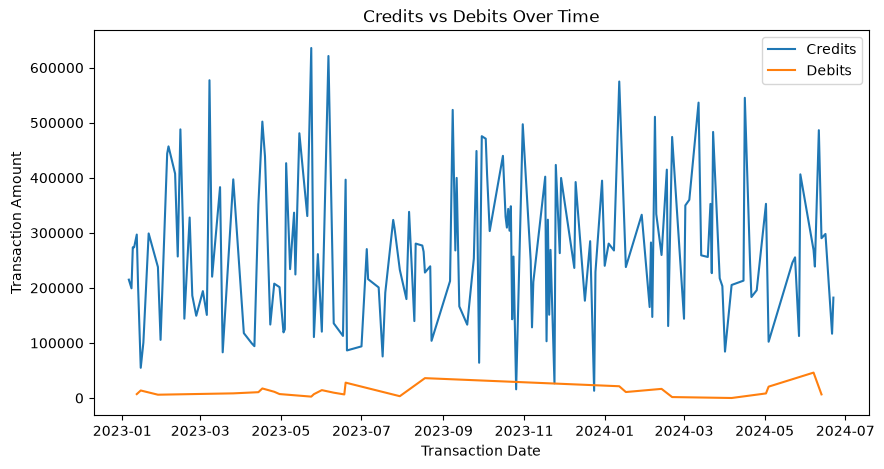

In [24]:
credits = df[df["TransactionAmount"] > 0].groupby("TransactionDate")["TransactionAmount"].sum()
debits = df[df["TransactionAmount"] < 0].groupby("TransactionDate")["TransactionAmount"].sum().abs()

plt.figure(figsize = (10,5))

x1 = credits.index
y1 = credits.values

x2 = debits.index
y2 = debits.values

plt.plot(x1, y1, label = "Credits")
plt.plot(x2, y2, label = "Debits")
plt.title("Credits vs Debits Over Time")
plt.xlabel("Transaction Date")
plt.ylabel("Transaction Amount")
plt.legend()
plt.show()

#### The line chart shows the trend in total credits and debits over the observed transaction period. 
#### Credit amounts fluctuate considerably over time, with several noticeable peaks and troughs.
#### Debit amounts remain substantially lower than credit amounts throughout the period, although they also show some variation. 
#### Overall, the chart indicates that the total value of positive transactions consistently exceeds the total value of negative transactions in the observed data.

## 3. Identify top and bottom performing accounts based on net inflow. 

In [25]:
account_inflow = df.groupby("AccountID")[["Credits","Debits"]].sum().reset_index()
account_inflow["NetInflow"] = (account_inflow["Credits"] - account_inflow["Debits"])
account_inflow

,AccountID,Credits,Debits,NetInflow
0,ACC10117,246887.29,0.00,246887.29
1,ACC10996,358817.02,0.00,358817.02
2,ACC11062,328776.97,0.00,328776.97
3,ACC11188,386419.02,0.00,386419.02
4,ACC11285,284440.53,0.00,284440.53
...,...,...,...,...
187,ACC97225,106202.50,0.00,106202.50
188,ACC97411,435483.06,18823.16,416659.90
189,ACC99117,92159.60,0.00,92159.60
190,ACC99409,166502.66,10992.91,155509.75


#### Top Performing Accounts

In [26]:
top_accounts = account_inflow.sort_values(by = "NetInflow", ascending = False)
top_accounts.head()

,AccountID,Credits,Debits,NetInflow
77,ACC41829,765315.96,0.00,765315.96
121,ACC62446,665019.42,0.00,665019.42
185,ACC96277,513842.94,0.00,513842.94
83,ACC45101,511196.86,0.00,511196.86
144,ACC76549,484644.21,0.00,484644.21


#### Bottom Performing Accounts

In [27]:
bottom_accounts = account_inflow.sort_values(by = "NetInflow", ascending = True)
bottom_accounts.head()

,AccountID,Credits,Debits,NetInflow
35,ACC25132,10392.70,0.00,10392.70
60,ACC33287,36818.17,6489.54,30328.63
30,ACC23985,36112.77,2530.58,33582.19
7,ACC12334,38041.88,0.00,38041.88
116,ACC58078,41777.17,0.00,41777.17


## 4. Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.

In [28]:
df = df.sort_values(["AccountID","TransactionDate"])
df["TransactionGap"] = df.groupby("AccountID")["TransactionDate"].diff()

status = df.groupby("AccountID")["TransactionGap"].last().reset_index()
status["AccountStatus"] = np.where(status["TransactionGap"] >= "60 days", "Inactive", "Active")
status

,AccountID,TransactionGap,AccountStatus
0,ACC10117,104 days,Inactive
1,ACC10996,109 days,Inactive
2,ACC11062,204 days,Inactive
3,ACC11188,26 days,Active
4,ACC11285,142 days,Inactive
...,...,...,...
187,ACC97225,47 days,Active
188,ACC97411,14 days,Active
189,ACC99117,NaT,Active
190,ACC99409,133 days,Inactive


#### The transactions are sorted by AccountID in chronological order to calculate the difference between the current transaction date and the previous transaction date for each account. The difference between two transaction dates for each account is calculated in days. There are total 192 distinct accounts. For a account to be identified as "Active" or "Inactive", the latest transaction gap is taken into consideration. If the difference between the consecutive transactions of each account is 60 days(2 months) or more, then that account is flagged as "Inactive" and if it less than 60 days then it is flagged as "Active". 
#### The account with one time transaction are flagged as "Active" because the condition states to flag accounts as "Inactive" only when the gap is of 2 months are more.

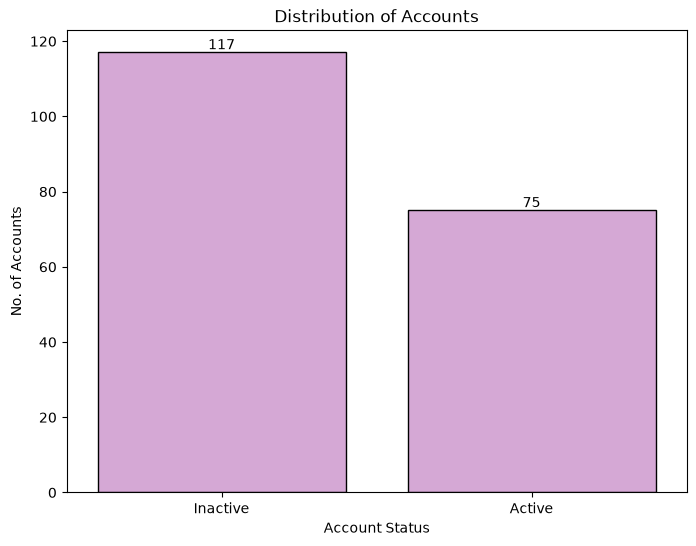

In [29]:
plt.figure(figsize=(8,6))
order = ["Inactive", "Active"]
plot = sns.countplot(x = "AccountStatus", data = status, 
                     order = order, color = "plum", edgecolor = "black")
plt.title("Distribution of Accounts")
plt.xlabel("Account Status")
plt.ylabel("No. of Accounts")
plot.bar_label(plot.containers[0])
plt.show()

#### After identifying and flagging accounts, it is found out that there are more inactive or dormant accounts than the active accounts. There are 117 dormant accounts and 75 active accounts.

# Task 3: Customer Profile Building

## 1. Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.

In [30]:
account_activity = df.groupby("AccountID")["TransactionID"].count()
account_activity = account_activity.reset_index()
account_activity.columns = ["AccountID", "TransactionFrequency"]
account_activity

,AccountID,TransactionFrequency
0,ACC10117,6
1,ACC10996,4
2,ACC11062,6
3,ACC11188,9
4,ACC11285,5
...,...,...
187,ACC97225,3
188,ACC97411,8
189,ACC99117,1
190,ACC99409,3


In [31]:
account_activity["TransactionFrequency"].unique()

array([ 6,  4,  9,  5,  3,  2,  1,  7,  8, 13])

#### The Transaction Frequency values are ranging from 1 to 9. And one value is 13

In [32]:
ds = account_activity.groupby("TransactionFrequency")["AccountID"].count().reset_index()
ds.columns = ["TransactionFrequency", "No. of Accounts"]
ds

,TransactionFrequency,No. of Accounts
0,1,8
1,2,34
2,3,37
3,4,48
4,5,20
5,6,17
6,7,15
7,8,7
8,9,5
9,13,1


#### This dataframe gives the information on the transaction frequency and the number of accounts with that transaction frequency.
#### The Transaction Frequency range from 1 to 9 and only one account has made 13 transactions making 13 as the outlier in this case. 

### Activity Level Segmentation
#### High Activity : >= 7 Transactions , Medium Activity : 4-6 transactions, Low Activity: <= 3 transactions
#### The activity levels are grouped based on transaction frequency observed in the dataset. Accounts with 1–3 transactions are classified as Low activity, 4–6 transactions as Medium activity, and 7 or more transactions as High activity. These boundaries distinguish accounts with relatively infrequent, moderate, and frequent transaction activity while keeping the categories simple and interpretable.

In [33]:
account_activity["ActivityLevel"] = np.where(account_activity["TransactionFrequency"] >= 7, "High", 
                                    np.where(account_activity["TransactionFrequency"] >= 4, "Medium", "Low"))
account_activity

,AccountID,TransactionFrequency,ActivityLevel
0,ACC10117,6,Medium
1,ACC10996,4,Medium
2,ACC11062,6,Medium
3,ACC11188,9,High
4,ACC11285,5,Medium
...,...,...,...
187,ACC97225,3,Low
188,ACC97411,8,High
189,ACC99117,1,Low
190,ACC99409,3,Low


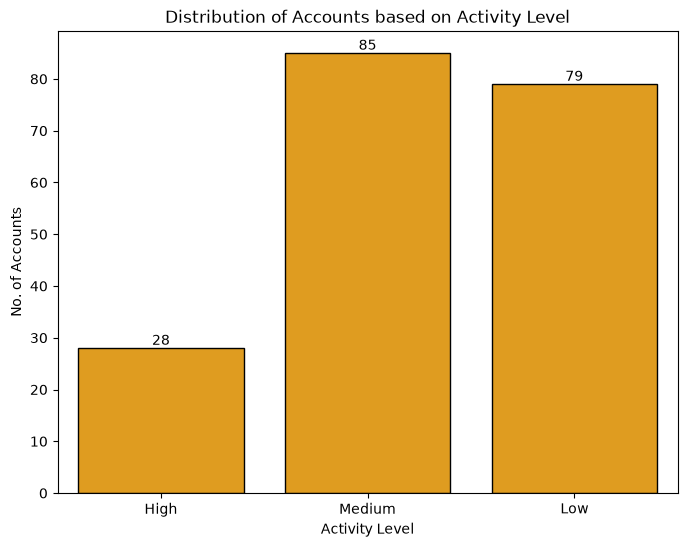

In [34]:
plt.figure(figsize=(8,6))
order = ["High", "Medium", "Low"]
plot = sns.countplot(x = "ActivityLevel", data = account_activity, 
                     order = order, color = "orange", edgecolor = "black")
plt.title("Distribution of Accounts based on Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("No. of Accounts")
plot.bar_label(plot.containers[0])
plt.show()

## 2. Segment customers by average balance and transaction volume. 

In [35]:
customer_segment = df.groupby("CustomerID").agg(
    AvgBalance = ("AccountBalance", "mean"),
    TransactionVolume = ("TransactionAmount",lambda x: abs(x).sum())
)
customer_segment = customer_segment.reset_index()
customer_segment

,CustomerID,AvgBalance,TransactionVolume
0,CUST1042,79417.27,353164.39
1,CUST1114,51474.22,140127.07
2,CUST1121,63924.64,281314.80
3,CUST1189,39051.94,95697.31
4,CUST1223,76370.22,284909.64
...,...,...,...
175,CUST9683,67171.23,407536.43
176,CUST9731,56981.19,176344.29
177,CUST9754,48462.83,283654.48
178,CUST9843,44101.31,203798.70


In [36]:
customer_segment[["AvgBalance", "TransactionVolume"]].describe()

,AvgBalance,TransactionVolume
count,180.00,180.00
mean,72602.14,245798.81
std,19475.22,119462.69
min,4873.36,26129.18
25%,62003.63,160265.32
50%,72510.36,229224.32
75%,85062.28,315712.08
max,137652.01,614265.02


In [37]:
balance_median = customer_segment["AvgBalance"].median()
volume_median = customer_segment["TransactionVolume"].median()

print(balance_median)
print(volume_median)

72510.3555275
229224.3156205


### Customer Segmentation
#### High Value if AvgBalance >= median  & TransactionVolume >= median, Low Value if AvgBalance < median & TransactionVolume < median, Balance-Focused if AvgBalance >= median  & TransactionVolume < median or Transaction-Focused  if AvgBalance < median & TransactionVolume >= median
#### The median is used as the boundary because it represents the midpoint of the observed customer distribution. This provides a data-driven distinction between customers with relatively lower and higher average balances and transaction volumes, rather than using arbitrary fixed thresholds.

In [38]:
customer_segment["CustomerSegment"] = np.where(
        (customer_segment["AvgBalance"] >= balance_median) &
        (customer_segment["TransactionVolume"] >= volume_median), "High Value",
    np.where(
        (customer_segment["AvgBalance"] < balance_median) &
        (customer_segment["TransactionVolume"] < volume_median),"Low Value",
            np.where(
        (customer_segment["AvgBalance"] >= balance_median) &
        (customer_segment["TransactionVolume"] < volume_median),"Balance-Focused","Transaction-Focused"
    )
    )
)
customer_segment.head()

,CustomerID,AvgBalance,TransactionVolume,CustomerSegment
0,CUST1042,79417.27,353164.39,High Value
1,CUST1114,51474.22,140127.07,Low Value
2,CUST1121,63924.64,281314.80,Transaction-Focused
3,CUST1189,39051.94,95697.31,Low Value
4,CUST1223,76370.22,284909.64,High Value


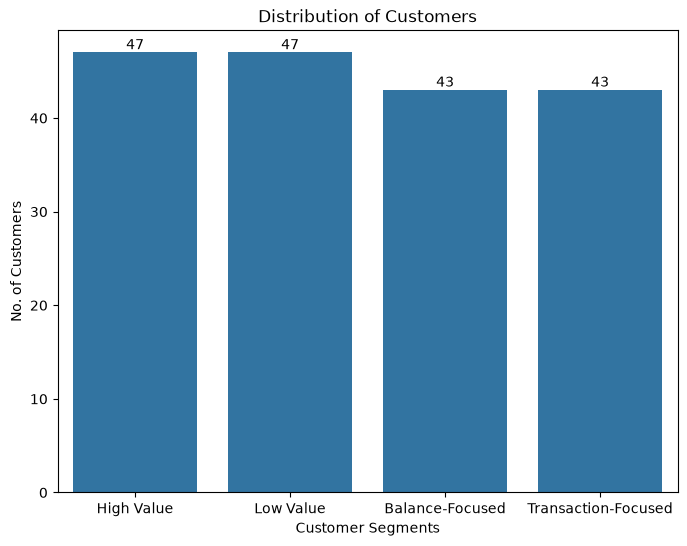

In [39]:
plt.figure(figsize=(8,6))
order = ["High Value", "Low Value", "Balance-Focused", "Transaction-Focused"]
plot = sns.countplot(x = "CustomerSegment", data = customer_segment, 
                     order = order)
plt.title("Distribution of Customers")
plt.xlabel("Customer Segments")
plt.ylabel("No. of Customers")
plot.bar_label(plot.containers[0])
plt.show()

## 3. Create profiles for: 
## ○ High-net inflow accounts 
## ○ High-frequency low-balance accounts 
## ○ Accounts with negative or near-zero balances 

In [40]:
profile = df.groupby("AccountID")[["Credits","Debits"]].sum()
profile["NetInflow"] = (profile["Credits"] - profile["Debits"])
profile["TransactionFrequency"] = df.groupby("AccountID")["TransactionID"].count()
profile["AvgBalance"] = df.groupby("AccountID")["AccountBalance"].mean()
profile["MinimumBalance"] = df.groupby("AccountID")["AccountBalance"].min()
profile = profile.reset_index()
profile

,AccountID,Credits,Debits,NetInflow,TransactionFrequency,AvgBalance,MinimumBalance
0,ACC10117,246887.29,0.00,246887.29,6,81106.21,33798.37
1,ACC10996,358817.02,0.00,358817.02,4,101733.90,91106.10
2,ACC11062,328776.97,0.00,328776.97,6,57108.76,-9084.22
3,ACC11188,386419.02,0.00,386419.02,9,80235.15,47773.37
4,ACC11285,284440.53,0.00,284440.53,5,71205.65,36464.73
...,...,...,...,...,...,...,...
187,ACC97225,106202.50,0.00,106202.50,3,53496.78,-3049.41
188,ACC97411,435483.06,18823.16,416659.90,8,89407.83,49011.68
189,ACC99117,92159.60,0.00,92159.60,1,106391.25,106391.25
190,ACC99409,166502.66,10992.91,155509.75,3,55933.33,2730.90


#### Net Inflow is calculated as the difference between credits and debits which reflects the actual cash flow. Transaction Frequency is the number of transactions made by an account. The average of Account Balance shows the balance maintained in an account on average.

In [41]:
print(profile["NetInflow"].max())
print(profile["NetInflow"].min())

765315.96385
10392.70245


In [42]:
print(profile["AvgBalance"].max())
print(profile["AvgBalance"].min())

171767.6578
23319.336055249998


#### High-net inflow accounts are identified from accounts with postitive net inflow. The 75th percentile of positive net inflow is used as the threshold, so accounts in the top 25% of positive net inflow are classified as High-net inflow accounts. 
#### High-frequency accounts are defined as accounts with 7 or more transactions, based on the frequency distribution established earlier. Low-balance accounts were defined using the 25th percentile of average account balance. Accounts satisfyting both conditions are classified as High-frequency low-balance accounts.
#### The minimum balance of each account is used to identify accounts that experienced particularly low balances. The 10th percentile of the account-level minimum balances is selected as the threshold for negative or near-zero balances. This identifies accounts whose minimum balance falls within the lowest 10% of observed account minimum balances, providing a data-driven definition of accounts that reached unusually low balance levels.

In [43]:
inflow_threshold = profile[profile["NetInflow"] > 0]["NetInflow"].quantile(0.75)
low_balance_threshold = profile["AvgBalance"].quantile(0.25)
near_zero_threshold = profile["MinimumBalance"].quantile(0.10)

In [44]:
profile["AccountProfile"] = np.where(profile["NetInflow"] >= inflow_threshold, "High-Net Inflow", 
    np.where((profile["TransactionFrequency"] >= 7) & (profile["AvgBalance"] <= low_balance_threshold), "High-frequency Low-balance",
    np.where(profile["MinimumBalance"] <= near_zero_threshold, "Negative/Near-Zero Balance","Other"))
)
profile

,AccountID,Credits,Debits,NetInflow,TransactionFrequency,AvgBalance,MinimumBalance,AccountProfile
0,ACC10117,246887.29,0.00,246887.29,6,81106.21,33798.37,Other
1,ACC10996,358817.02,0.00,358817.02,4,101733.90,91106.10,High-Net Inflow
2,ACC11062,328776.97,0.00,328776.97,6,57108.76,-9084.22,High-Net Inflow
3,ACC11188,386419.02,0.00,386419.02,9,80235.15,47773.37,High-Net Inflow
4,ACC11285,284440.53,0.00,284440.53,5,71205.65,36464.73,Other
...,...,...,...,...,...,...,...,...
187,ACC97225,106202.50,0.00,106202.50,3,53496.78,-3049.41,Negative/Near-Zero Balance
188,ACC97411,435483.06,18823.16,416659.90,8,89407.83,49011.68,High-Net Inflow
189,ACC99117,92159.60,0.00,92159.60,1,106391.25,106391.25,Other
190,ACC99409,166502.66,10992.91,155509.75,3,55933.33,2730.90,Other


In [45]:
profile[profile['AccountProfile'] == "High-Net Inflow"]

,AccountID,Credits,Debits,NetInflow,TransactionFrequency,AvgBalance,MinimumBalance,AccountProfile
1,ACC10996,358817.02,0.00,358817.02,4,101733.90,91106.10,High-Net Inflow
2,ACC11062,328776.97,0.00,328776.97,6,57108.76,-9084.22,High-Net Inflow
3,ACC11188,386419.02,0.00,386419.02,9,80235.15,47773.37,High-Net Inflow
13,ACC16241,468854.28,0.00,468854.28,9,84908.40,58174.08,High-Net Inflow
17,ACC18140,318038.14,0.00,318038.14,4,65493.64,34360.89,High-Net Inflow
31,ACC24070,338136.69,0.00,338136.69,5,53811.39,12642.43,High-Net Inflow
36,ACC25811,345861.70,0.00,345861.70,7,79173.97,52874.03,High-Net Inflow
41,ACC28154,442122.89,0.00,442122.89,9,69366.70,49832.09,High-Net Inflow
43,ACC28295,324723.73,0.00,324723.73,4,125043.31,99148.69,High-Net Inflow
47,ACC29231,371100.94,0.00,371100.94,6,102089.72,69004.46,High-Net Inflow


In [46]:
profile[profile['AccountProfile'] == "High-frequency Low-balance"]

,AccountID,Credits,Debits,NetInflow,TransactionFrequency,AvgBalance,MinimumBalance,AccountProfile
82,ACC43771,245338.26,14311.68,231026.57,8,59242.76,33132.56,High-frequency Low-balance
84,ACC45521,268616.53,0.00,268616.53,7,49875.37,-18963.80,High-frequency Low-balance


In [47]:
profile[profile['AccountProfile'] ==  "Negative/Near-Zero Balance"]

,AccountID,Credits,Debits,NetInflow,TransactionFrequency,AvgBalance,MinimumBalance,AccountProfile
11,ACC15671,134497.96,0.00,134497.96,3,27077.57,-8225.60,Negative/Near-Zero Balance
26,ACC22036,221635.96,0.00,221635.96,6,74872.56,-4547.37,Negative/Near-Zero Balance
44,ACC28305,196399.10,0.00,196399.10,4,71076.24,1775.68,Negative/Near-Zero Balance
64,ACC34821,222247.32,0.00,222247.32,4,23319.34,-32532.52,Negative/Near-Zero Balance
73,ACC39529,145169.77,0.00,145169.77,3,62774.93,-35891.00,Negative/Near-Zero Balance
89,ACC46953,139047.72,0.00,139047.72,2,35656.16,-26968.23,Negative/Near-Zero Balance
123,ACC64022,219205.79,0.00,219205.79,5,75321.46,-11356.98,Negative/Near-Zero Balance
141,ACC74631,183823.54,0.00,183823.54,5,64076.89,-8820.48,Negative/Near-Zero Balance
143,ACC75675,140799.24,0.00,140799.24,3,57655.97,243.76,Negative/Near-Zero Balance
154,ACC78589,153513.18,0.00,153513.18,3,34272.67,-25971.51,Negative/Near-Zero Balance


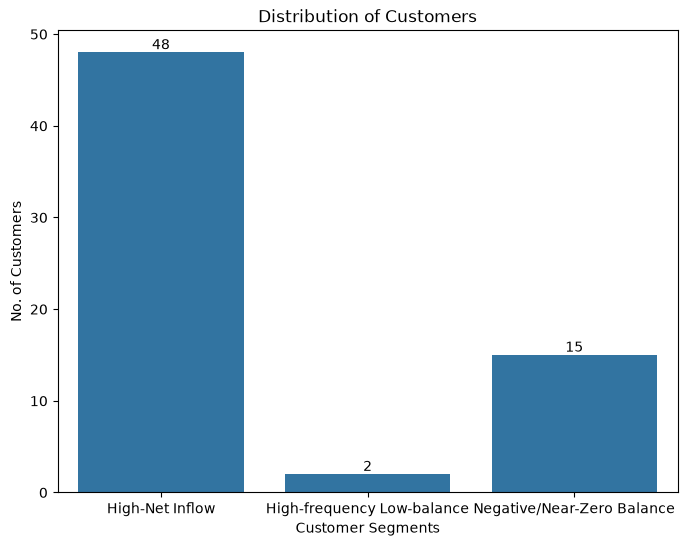

In [48]:
plt.figure(figsize=(8,6))
order = ["High-Net Inflow", "High-frequency Low-balance", "Negative/Near-Zero Balance"]
plot = sns.countplot(x = "AccountProfile", data = profile, 
                     order = order)
plt.title("Distribution of Customers")
plt.xlabel("Customer Segments")
plt.ylabel("No. of Customers")
plot.bar_label(plot.containers[0])
plt.show()

# Task 4: Financial Risk Identification

## 1. Track accounts with frequent large withdrawals or overdrafts. 

In [49]:
withdrawals = df[(df["TransactionType"] == "Withdrawal") & (df["TransactionAmount"] < 0)]
track = withdrawals[["AccountID","TransactionAmount"]]
threshold = track["TransactionAmount"].abs().quantile(0.90)
track['LargeWithdrawal'] = track["TransactionAmount"].abs() >= threshold
track

,AccountID,TransactionAmount,LargeWithdrawal
404,ACC22799,-5618.65,False
462,ACC33287,-6489.54,False
494,ACC57700,-20633.96,True
104,ACC77592,-7084.03,False
41,ACC78581,-1714.01,False
400,ACC83005,-11328.78,False


In [50]:
print(threshold)
print(track["TransactionAmount"].max())

15981.365515000001
-1714.007479


#### The Transactions type 'Withdrawal' is considered for identifying large withdrawals because it is explicitly recorded as a withdrawwal in the dataset.Transactions with negative amounts are considered to represent money leaving the account. A percentile-based threshold is used to identify unusually large withdrawals, where the top 10% transactions are classified as 'Large Withdrawals'.

In [51]:
frequency = track.groupby("AccountID")["LargeWithdrawal"].sum().reset_index()
frequency["FrequentLargeWithdrawal"] = (frequency["LargeWithdrawal"] >= 2)
frequency

,AccountID,LargeWithdrawal,FrequentLargeWithdrawal
0,ACC22799,0,False
1,ACC33287,0,False
2,ACC57700,1,False
3,ACC77592,0,False
4,ACC78581,0,False
5,ACC83005,0,False


In [52]:
account = frequency[frequency["FrequentLargeWithdrawal"] == True]
account

,AccountID,LargeWithdrawal,FrequentLargeWithdrawal


#### A 90th-percentile threshold of 15981.37 was used to identify large withdrawals, representing the top 10% of withdrawal transactions. The frequency analysis shows that accounts recorded either zero or one large withdrawal. Therefore, no accounts were identified as having frequent large withdrawals during the observed period.

In [53]:
overdraft_accounts = df[df["AccountBalance"] < 0].groupby("AccountID")["AccountBalance"].min()
overdraft_accounts = overdraft_accounts.reset_index()
overdraft_accounts

,AccountID,AccountBalance
0,ACC11062,-9084.22
1,ACC15671,-8225.60
2,ACC22036,-4547.37
3,ACC30787,-3069.41
4,ACC34821,-32532.52
5,ACC39529,-35891.00
6,ACC45101,-505.92
7,ACC45521,-18963.80
8,ACC46953,-26968.23
9,ACC64022,-11356.98


#### The accounts with negative balance are the overdrafts account. Only transactions with negative account balances were considered. These were grouped by AccountID to identify overdraft accounts, and for each account, the minimum balance was selected to capture the most severe overdraft case. The accounts here show that at one point in time they had a negative balance

## 2. Calculate balance volatility using standard deviation or coefficient of variation.

In [54]:
volatility = df.groupby("AccountID").agg(
    StandardDeviation = ("AccountBalance", "std"),
    Mean = ("AccountBalance", "mean")
)
volatility = volatility.reset_index()
volatility["CoV"] = (volatility["StandardDeviation"] / volatility["Mean"])
volatility.head(7)

,AccountID,StandardDeviation,Mean,CoV
0,ACC10117,30732.94,81106.21,0.38
1,ACC10996,12477.43,101733.90,0.12
2,ACC11062,40017.80,57108.76,0.70
3,ACC11188,25420.45,80235.15,0.32
4,ACC11285,35772.56,71205.65,0.50
5,ACC11837,21045.25,69822.57,0.30
6,ACC12182,11495.22,103956.45,0.11


#### Balance Volatility is calculated at account level using Standard Deviation and Coefficient of Variation. Standard Deviation measures the absolute variation in an account's balance, while CoV measures the variation relative to its average balance. These measures allow differences in balance fluctuations across accounts to be assessed using statistical measures.

In [55]:
sd = df["AccountBalance"].std()
print("Standard Deviation: ", sd)

Standard Deviation:  34206.07205897809


In [56]:
std = df["AccountBalance"].std()
mean = df["AccountBalance"].mean()
cv = std / mean
print("Coefficient of Variation: ", cv)

Coefficient of Variation:  0.46891605800319447


#### Overall Balance volatility is also calculated across all account balances to measure the extent of variation in balance across the dataset.

## 3. Use IQR or z-score methods to detect anomalies.

In [57]:
Q1 = df["TransactionAmount"].quantile(0.25)
Q3 = df["TransactionAmount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
anomaly = df[(df["TransactionAmount"] < lower) | (df["TransactionAmount"] > upper)]

print(f"IQR : {IQR}")
print(f"Lower Bound : {lower}, Upper Bound : {upper}")
print(f"Number of Outliers : {anomaly.shape[0]}")
sorting = anomaly.sort_values(by = 'TransactionAmount', ascending = True)
sorting[["AccountID","TransactionAmount"]]

IQR : 38884.865737500004
Lower Bound : -23726.616456250013, Upper Bound : 131812.84649375
Number of Outliers : 7


,AccountID,TransactionAmount
481,ACC88449,-27916.91
640,ACC94203,-27308.24
377,ACC83848,137999.19
306,ACC41829,144271.27
264,ACC18057,144421.84
168,ACC21719,155241.43
755,ACC45101,165004.54


In [58]:
Q1 = df["AccountBalance"].quantile(0.25)
Q3 = df["AccountBalance"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["AccountBalance"] < lower) | (df["AccountBalance"] > upper)]

print(f"IQR : {IQR}")
print(f"Lower Bound : {lower}, Upper Bound : {upper}")
print(f"Number of Outliers : {outliers.shape[0]}")
sorting = outliers.sort_values(by = 'AccountBalance', ascending = True)
sorting[["AccountID","AccountBalance"]]

IQR : 43420.167214999994
Lower Bound : -13997.192927499986, Upper Bound : 159683.47593249998
Number of Outliers : 12


,AccountID,AccountBalance
733,ACC39529,-35891.00
642,ACC34821,-32532.52
258,ACC46953,-26968.23
107,ACC78589,-25971.51
739,ACC45521,-18963.80
117,ACC29646,160302.74
309,ACC76549,161174.87
349,ACC71426,162291.35
444,ACC28295,163654.25
437,ACC88252,164049.71


#### Anomaly or Outlier detection is done on the numerical columns, AccountBalance and TransactionAmount using IQR method.
#### The Interquartile Range (IQR) is calculated for the numerical variables, TransactionAmount and AccountBalance, to determine the spread of the data. Based on the IQR, lower and upper bounds are defined to identify outliers, and the values falling outside these bounds are known as anomalies or outliers. The values are also sorted in ascending order to show the values clearly.

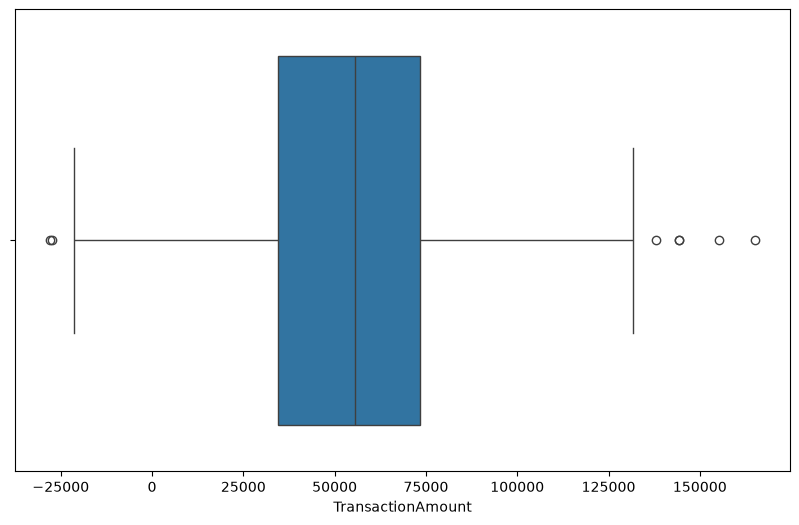

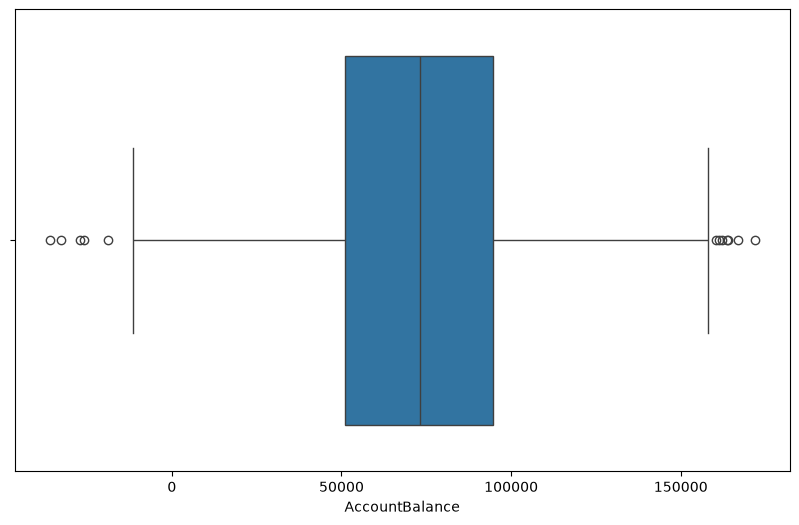

In [59]:
num_cols = df[["TransactionAmount", "AccountBalance"]]
for i in num_cols:
    plt.figure(figsize = (10,6))
    sns.boxplot(x = df[i])
    plt.show()

#### A boxplot is used to visually represent the distribution of data in these numerical columns and identify the outliers 

## 4. Highlight customers with irregular or suspicious transaction behavior.

In [60]:
anomaly[["CustomerID","TransactionAmount"]]

,CustomerID,TransactionAmount
264,CUST4780,144421.84
168,CUST2443,155241.43
306,CUST6565,144271.27
755,CUST1888,165004.54
377,CUST1042,137999.19
481,CUST7793,-27916.91
640,CUST1962,-27308.24


#### Customers associated with the TransactionAmount outliers identified using the IQR method are highlighted. These customers have transaction amounts that fall outside the statistically expected range and therefore represent unusual transaction activity. 

In [61]:
customer_count = df.groupby("CustomerID")["TransactionID"].count().reset_index()
customer_count.columns = ["CustomerID", "TransactionFrequency"]

In [62]:
cd = customer_count.groupby("TransactionFrequency")["CustomerID"].count().reset_index()
cd.columns = ["TransactionFrequency", "No. of Customers"]
cd

,TransactionFrequency,No. of Customers
0,1,8
1,2,18
2,3,38
3,4,33
4,5,33
5,6,25
6,7,15
7,8,3
8,9,5
9,10,1


In [63]:
extreme = customer_count[(customer_count["TransactionFrequency"] > 9)]
extreme

,CustomerID,TransactionFrequency
153,CUST8390,11
161,CUST9038,10


#### Customer Transaction frequency is also analysed to identify customers with unusually high numbers of transactions. The observed frequency ranged from 1 to 11 transactions, with only two customers having more than 9 transactions. These customers are highlighted because their transaction frequency is considerably higher than that of most customers. Combined with the IQR-based transaction outliers, transaction frequency provides an additional indicator for identifying customers with irregular transaction behaviour.

# Task 5 : Visualisation

## Conduct extensive exploratory data analysis with attractive visualizations for your findings 

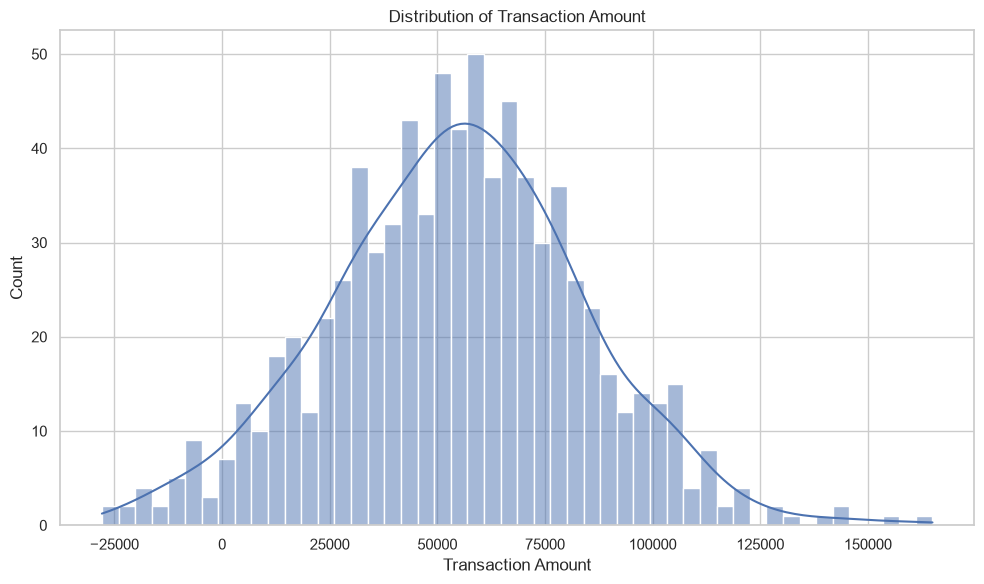

In [64]:
sns.set_theme(style="whitegrid")
plt.figure(figsize = (10,6))
sns.histplot(df["TransactionAmount"], bins = 50, kde = True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.tight_layout()
plt.show()

#### The distribution of Transaction Amount is approximately normal. There are few high-value transactions on the right end.

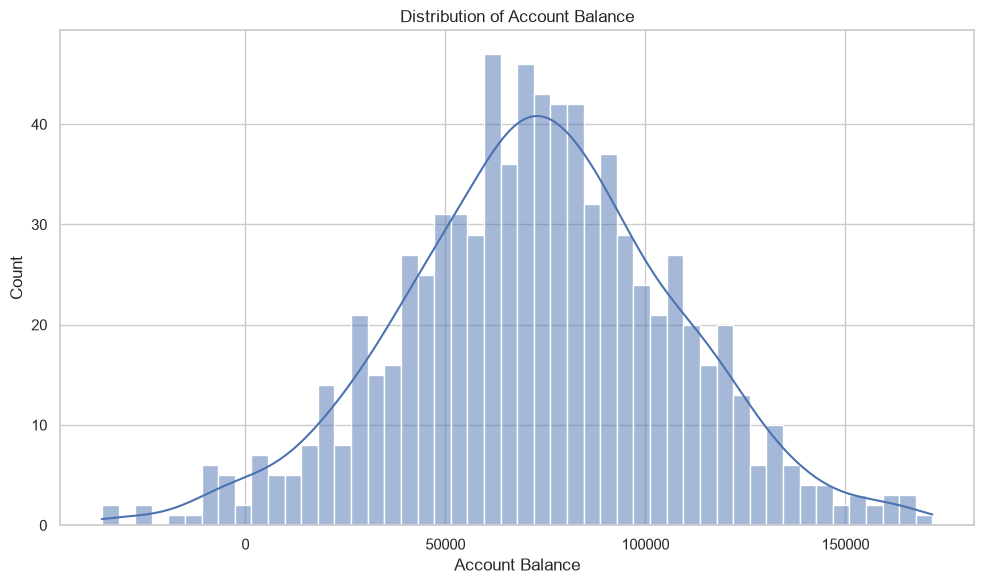

In [65]:
plt.figure(figsize = (10,6))
sns.histplot(df["AccountBalance"], bins = 50, kde = True)
plt.title("Distribution of Account Balance")
plt.xlabel("Account Balance")
plt.tight_layout()
plt.show()

### This plot indicates that the account balances are roughly normally distributed with few extremes on both the sides.

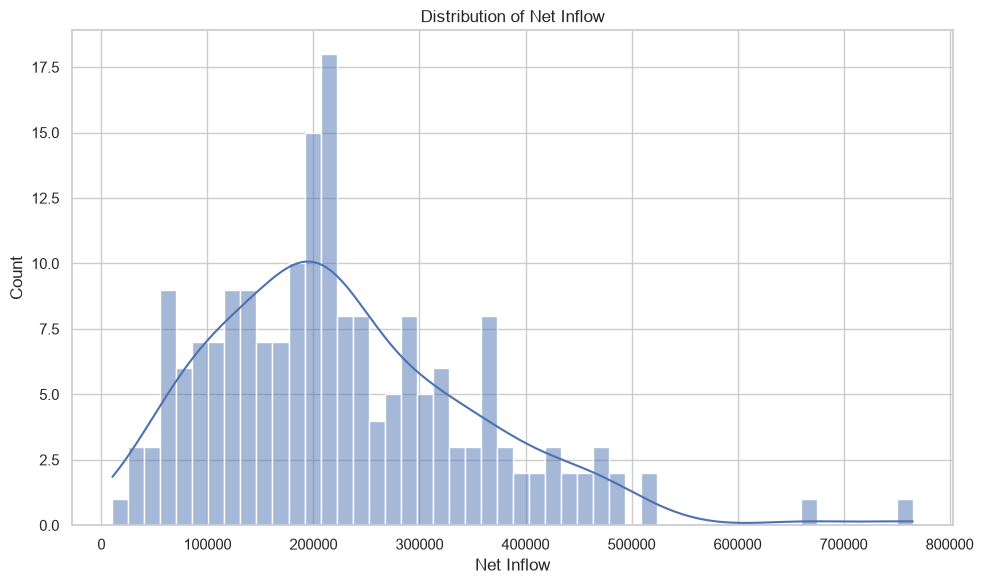

In [66]:
plt.figure(figsize = (10,6))
sns.histplot(account_inflow["NetInflow"], bins = 50, kde = True)
plt.title("Distribution of Net Inflow")
plt.xlabel("Net Inflow")
plt.tight_layout()
plt.show()

#### The net inflow is mostly centered in the negative range showing the withdrawals are more than the credits or deposits.

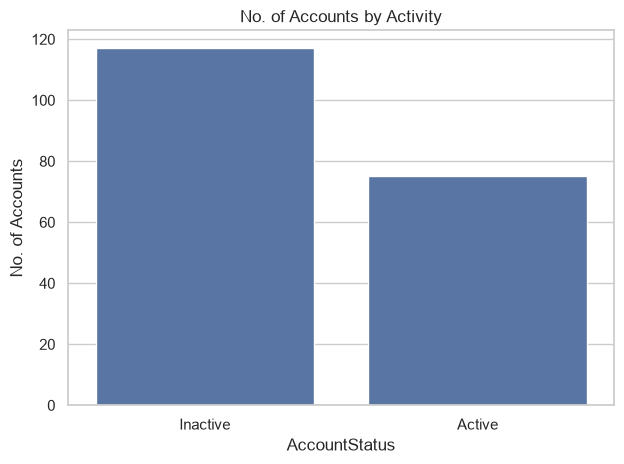

In [67]:
sns.countplot(x = status["AccountStatus"])
plt.xlabel('AccountStatus')
plt.ylabel('No. of Accounts')
plt.title('No. of Accounts by Activity')
plt.tight_layout()
plt.show()

#### The number of inactive accounts is significantly higher than the number of active accounts which suggets a large portion of customers are not regularly making transactions

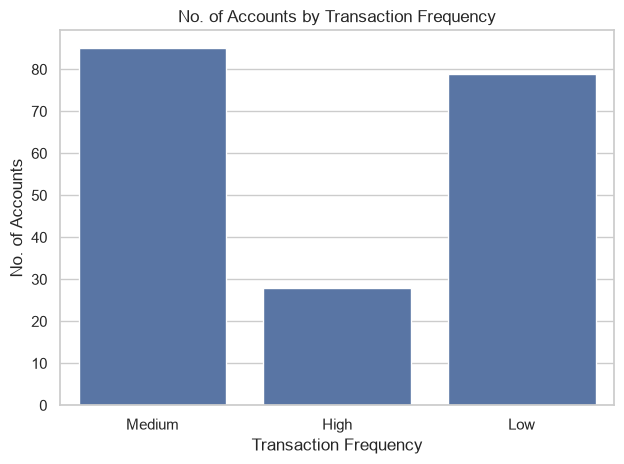

In [68]:
sns.countplot(x = account_activity["ActivityLevel"])
plt.title("No. of Accounts by Transaction Frequency")
plt.xlabel("Transaction Frequency")
plt.ylabel("No. of Accounts")
plt.tight_layout()
plt.show()

#### Most accounts fall into the medium and low transaction frequency categories indicating moderate to low engagement

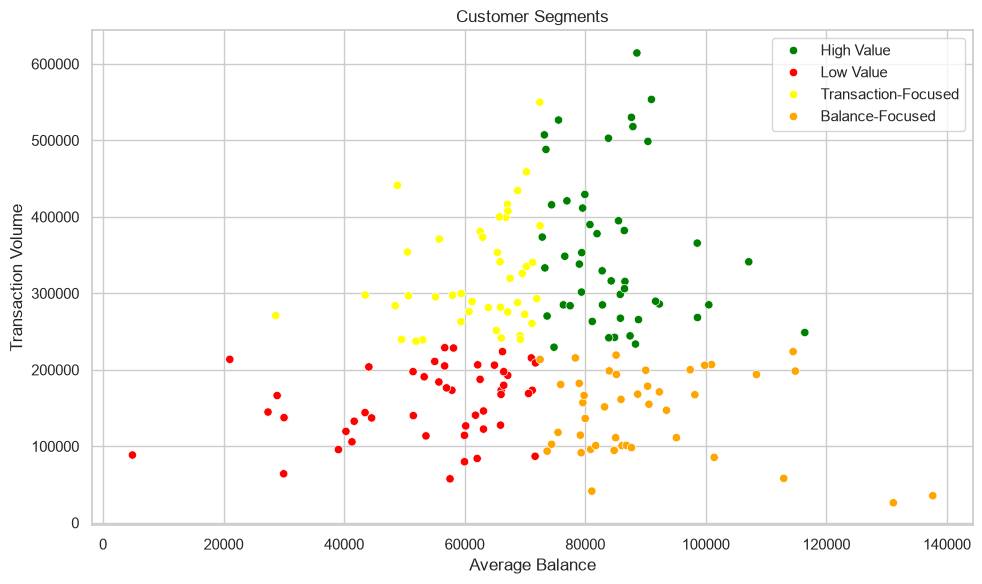

In [69]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = "AvgBalance", y = "TransactionVolume", hue = "CustomerSegment", 
                data = customer_segment,
                palette = {"High Value":"green", "Balance-Focused":"orange","Transaction-Focused":"yellow", "Low Value":"red"})
plt.title("Customer Segments")
plt.xlabel("Average Balance")
plt.ylabel("Transaction Volume")
plt.legend()
plt.tight_layout()
plt.show()

#### The scatter plot suggests the transaction volume increases with average balance, which indicates a positive relationship. However, some high balance accounts are active and others are relatively inactive.

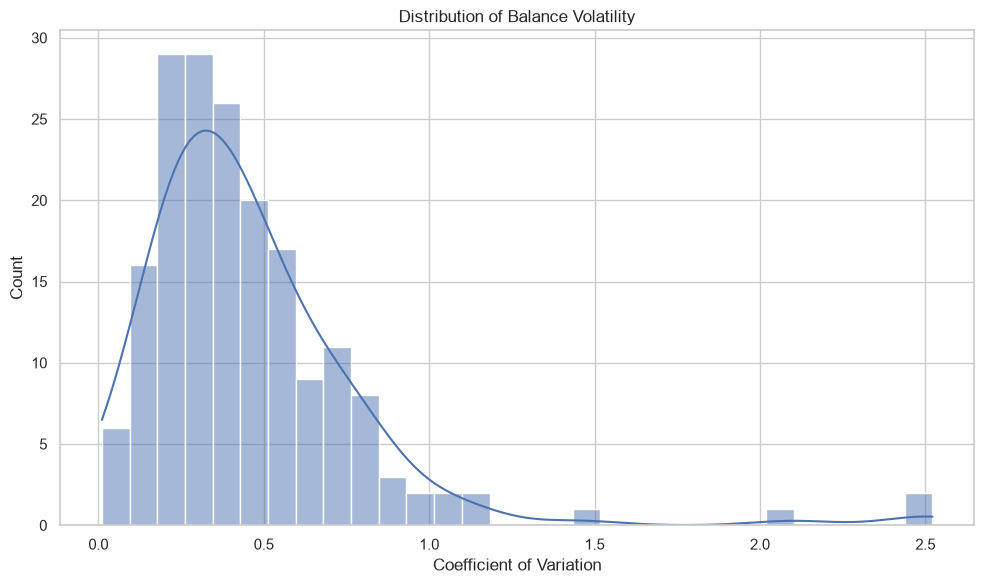

In [70]:
plt.figure(figsize = (10,6))
sns.histplot(volatility["CoV"], bins = 30, kde = True)
plt.title("Distribution of Balance Volatility")
plt.xlabel("Coefficient of Variation")
plt.tight_layout()
plt.show()

#### The distribution is heavily right skewed suggesting that most customers maintain stable account balances while a few show high volatile account balances

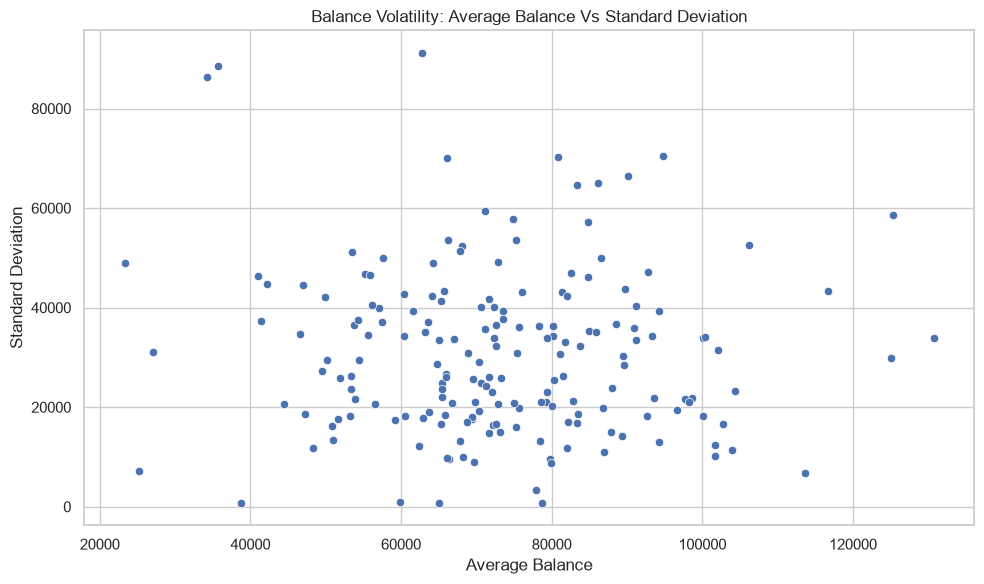

In [71]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = "Mean", y = "StandardDeviation", data = volatility)
plt.title("Balance Volatility: Average Balance Vs Standard Deviation")
plt.xlabel("Average Balance")
plt.ylabel("Standard Deviation")
plt.tight_layout()
plt.show()

#### The scatterplot indicates that there is no strong relationship between average balance and standard deviation. Balance Volatility is distributed across all accounts indicating fluctuations occur irrespective of the balance size.

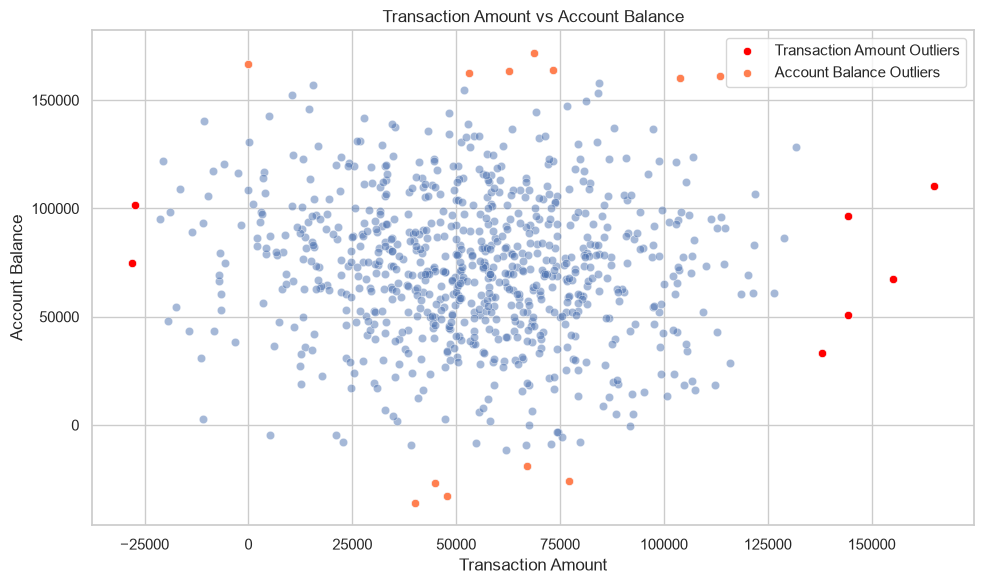

In [72]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = "TransactionAmount", y = "AccountBalance", data = df, alpha = 0.5)
sns.scatterplot(x = "TransactionAmount", y = "AccountBalance", data = anomaly, color = "red", label = "Transaction Amount Outliers")
sns.scatterplot(x = "TransactionAmount", y = "AccountBalance", data = outliers, color = "coral", label = "Account Balance Outliers")
plt.title("Transaction Amount vs Account Balance")
plt.xlabel("Transaction Amount")
plt.ylabel("Account Balance")
plt.tight_layout()
plt.show()

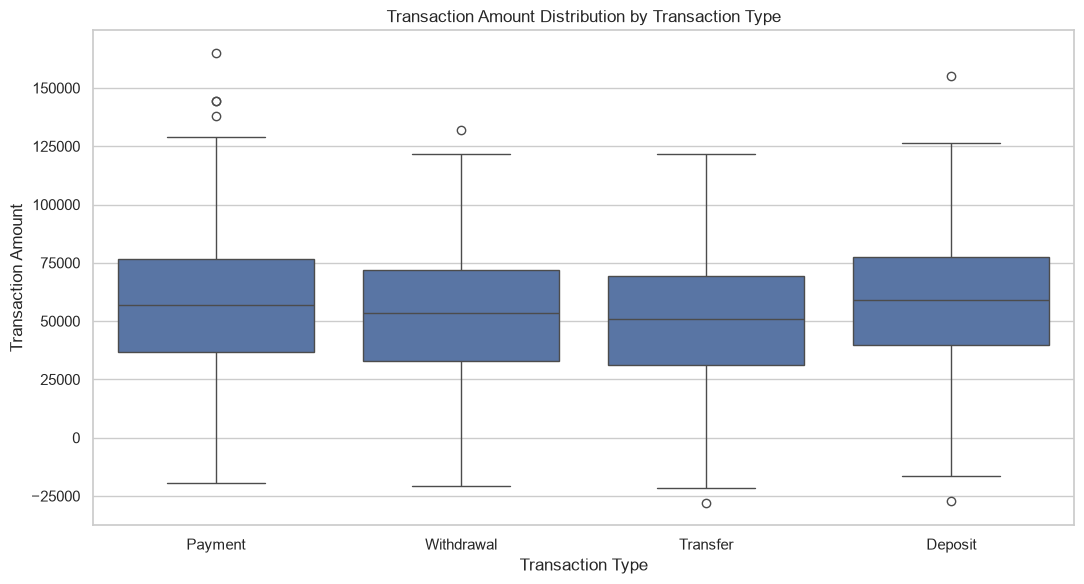

In [73]:
plt.figure(figsize = (11,6))
sns.boxplot(x = "TransactionType", y = "TransactionAmount", data = df) 
plt.title("Transaction Amount Distribution by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()

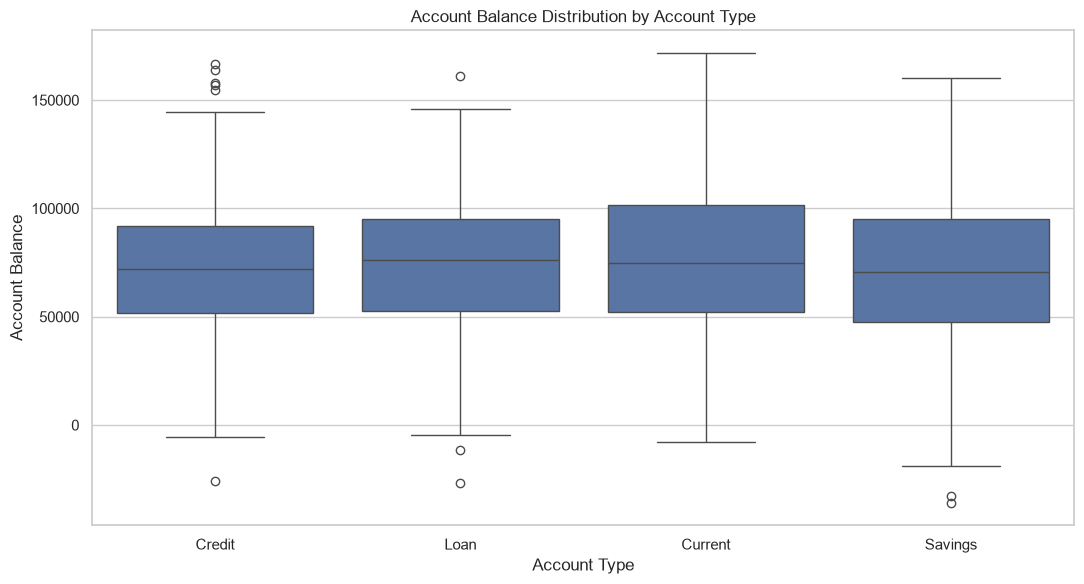

In [74]:
plt.figure(figsize = (11,6))
sns.boxplot(x = "AccountType", y = "AccountBalance", data = df)
plt.title("Account Balance Distribution by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Account Balance")
plt.tight_layout()
plt.show()

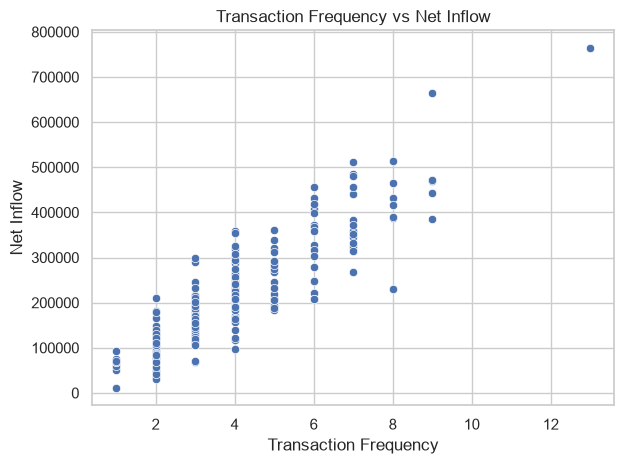

In [75]:
merged = account_activity.merge(account_inflow, on = "AccountID")
sns.scatterplot(x = "TransactionFrequency", y = "NetInflow", data = merged)
plt.title("Transaction Frequency vs Net Inflow")
plt.xlabel("Transaction Frequency")
plt.ylabel("Net Inflow")
plt.tight_layout()
plt.show()

#### There is no positive relationship between transaction frequency and net inflow. Many high frequency accounts show negative net inflows.

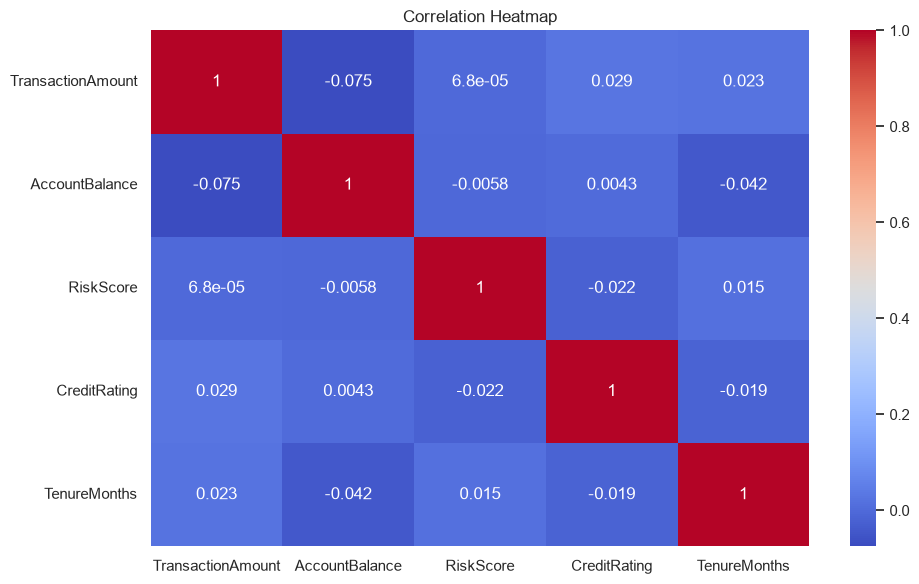

In [76]:
plt.figure(figsize = (10,6))
sns.heatmap(df[["TransactionAmount","AccountBalance","RiskScore","CreditRating","TenureMonths"]].corr(), annot=True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#### The variables show very weak or no relationship with each other meaning they mostly behave independently

# Task 6: Hypothesis Testing

## 1. Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.

### Defining Hypotheses
#### Null Hypothesis (H0) : High-volume transaction accounts do not have higher average balances than low-volume accounts.
#### Alternative Hypothesis(HA) : High-volume transaction accounts have higher average balances than low-volume accounts.

In [77]:
cs = df.groupby("AccountID").agg(
    AvgBalance = ("AccountBalance", "mean"),
    TransactionVolume = ("TransactionAmount",lambda x: abs(x).sum())
)
cs = cs.reset_index()
cs

,AccountID,AvgBalance,TransactionVolume
0,ACC10117,81106.21,246887.29
1,ACC10996,101733.90,358817.02
2,ACC11062,57108.76,328776.97
3,ACC11188,80235.15,386419.02
4,ACC11285,71205.65,284440.53
...,...,...,...
187,ACC97225,53496.78,106202.50
188,ACC97411,89407.83,454306.22
189,ACC99117,106391.25,92159.60
190,ACC99409,55933.33,177495.56


#### A table is created that includes account wise Average Balance and Transaction Volume

In [78]:
threshold = cs["TransactionVolume"].median()
print(threshold)

209869.80100500002


In [79]:
high_volume = cs[cs["TransactionVolume"] >= threshold]["AvgBalance"]
low_volume = cs[cs["TransactionVolume"] < threshold]["AvgBalance"]

#### The accounts are divided into high volume transaction and low volume transaction accounts such that the accounts with the transaction volume greater than or equal to the median value are considered as high volume and the remaining accounts are considered as low volume transaction accounts

#### The analysis compare the average balances of two independent groups : High-volume and low-volume transaction accounts. Their population standard deviations are unknown. Therefore, an independent two-sample t-test is appropriate. T-test is used because the population standard deviations are not known for the two groups and the test does not require the two groups to have equal variances.

In [94]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_volume, low_volume, alternative = 'greater')
print("t-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("\nReject the null hypothesis.")
    print("High-volume transaction accounts have statistically higher average balances than low-volume accounts.")
else:
    print("\nFail to reject the null hypothesis.")
    print("There is insufficient evidence that high-volume transaction accounts have higher average balances.")

t-statistic: -2.0191799725520663
P-value: 0.9775631109532605

Fail to reject the null hypothesis.
There is insufficient evidence that high-volume transaction accounts have higher average balances.


#### Since the p-value is greater than 0.05, we fail to reject the null hypothesis. Therefore, there is insufficient evidence that high-volume accounts have higher average balances than low-volume accounts.

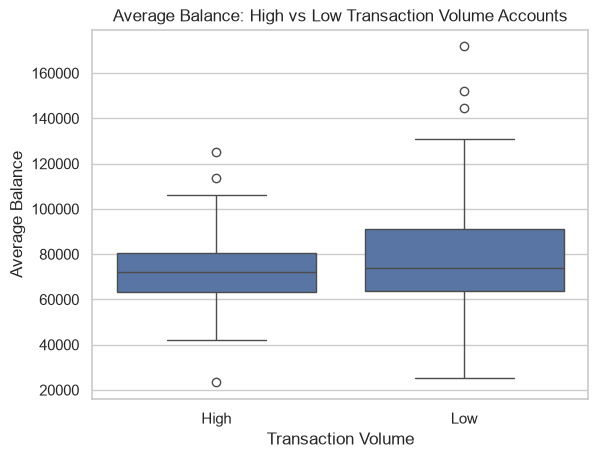

In [93]:
cs["VolumeGroup"] = np.where(cs["TransactionVolume"] >= threshold, "High", "Low")

sns.boxplot(x = "VolumeGroup", y = "AvgBalance", data = cs)
plt.title("Average Balance: High vs Low Transaction Volume Accounts")
plt.xlabel("Transaction Volume")
plt.ylabel("Average Balance")
plt.show()

#### The boxplot indicates that High-volume transaction accounts do not have higher average balances than low-volume accounts

## 2. Conduct hypothesis testing based on segmentation.

#### Hypothesis Testing is conducted on customer segmentation to test whether the Transaction Frequency differ significantly across the customer segments¶
#### Transaction Frequency is used to check if customer engagement differs across segments which validates if the segmentation reflects the actual transactional behaviour
#### Null Hypothesis (H0) : The mean transaction frequency is equal across all the customer segments
#### Alternative Hypothesis (HA) : The mean transaction frequency is not equal across all the customer segments. Atleast one  customer segment's mean transaction frequency is different.

In [95]:
merged2 = customer_segment.merge(customer_count, on = "CustomerID")
merged2

,CustomerID,AvgBalance,TransactionVolume,CustomerSegment,TransactionFrequency
0,CUST1042,79417.27,353164.39,High Value,6
1,CUST1114,51474.22,140127.07,Low Value,2
2,CUST1121,63924.64,281314.80,Transaction-Focused,5
3,CUST1189,39051.94,95697.31,Low Value,3
4,CUST1223,76370.22,284909.64,High Value,7
...,...,...,...,...,...
175,CUST9683,67171.23,407536.43,Transaction-Focused,7
176,CUST9731,56981.19,176344.29,Low Value,5
177,CUST9754,48462.83,283654.48,Transaction-Focused,4
178,CUST9843,44101.31,203798.70,Low Value,5


#### A table is created to include column from customer_segment and customer_count so that the table has CustomerSegment and TransactionFrequency
#### ANOVA is applied because it compares the mean transaction frequency across four customer segments to determine if there is a significant difference among them.
#### Customer Segment is a categorical variable with 4 groups, high, balance-focused, transaction-focused and low, so one way anova is applied to test whether the average transaction frequency differs across the segments

In [96]:
from scipy.stats import f_oneway

high = merged2[merged2["CustomerSegment"] == "High Value"]["TransactionFrequency"]
balance = merged2[merged2["CustomerSegment"] == "Balance-Focused"]["TransactionFrequency"]
transaction = merged2[merged2["CustomerSegment"] == "Transaction-Focused"]["TransactionFrequency"]
low = merged2[merged2["CustomerSegment"] == "Low Value"]["TransactionFrequency"]

f_stat, p_value = f_oneway(high, balance, transaction, low)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 59.47813209052201
P-value: 1.336156796112077e-26


In [98]:
alpha = 0.05
if p_value < alpha:
    print("\nReject the null hypothesis.")
    print("The mean transaction frequency is not equal across all the customer segments. Atleast one customer segment's mean transaction frequency is different.")
else:
    print("\nFail to reject the null hypothesis.")
    print("The mean transaction frequency is equal across all the customer segments.")


Reject the null hypothesis.
The mean transaction frequency is not equal across all the customer segments. Atleast one customer segment's mean transaction frequency is different.


#### f-oneway performs ANOVA.
#### The p-value is extremely small, below 0.05, it is in negative exponents meaning it is a very small value. There is no significant evidence to accept the null hypothesis. There is a significant difference in the transaction frequencies across the customer segments.
#### The mean transaction frequency is not equal across all the customer segments. Atleast one customer segment out of the four : High, Balance-Focused, Transaction-Focused and Low have significantly different mean transaction frequency.
#### However, ANOVA alone does not identify which specific segments differ from each other.

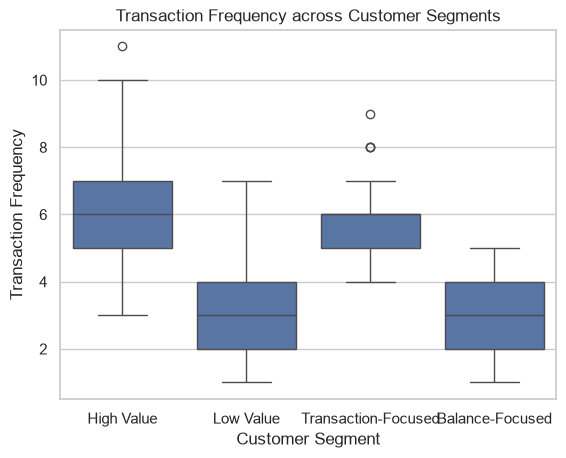

In [99]:
sns.boxplot(x = "CustomerSegment", y = "TransactionFrequency", data = merged2)
plt.title("Transaction Frequency across Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Transaction Frequency")
plt.show()

#### The boxplot indicates the customer segments have significantly different mean transaction frequency